In [42]:
#Import
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from xgboost import XGBClassifier

#Load data
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
train = train_df.copy()

# Process 1: Utilise name titles

In [43]:
# Extract title from Name
train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.')

# How many unique titles
unique_titles = train['Title'].unique()
print("Unique titles:", unique_titles)
print("Number of unique titles:", len(unique_titles))

Unique titles: ['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' 'the Countess' 'Jonkheer']
Number of unique titles: 17


**Understanding the data and titles, Miss and Master are mostly used for children**

In [51]:
#Utilise Name titles

# Median for Miss
median_miss = train.loc[train['Title'] == 'Miss', 'Age'].median()

# Median for others (excluding Miss)
median_other = train.loc[train['Title'] != 'Miss', 'Age'].median()

# Fill missing Age values
train.loc[(train['Age'].isna()) & (train['Title'] == 'Miss'), 'Age'] = median_miss
train.loc[(train['Age'].isna()) & (train['Title'] != 'Miss'), 'Age'] = median_other

# Create isChild column
train['isChild'] = ((train['Age'] <= 12) & (train['Title'] == 'Miss')) | (train['Title'] == 'Master')
train['isChild'] = train['isChild'].astype(int)

train['isAdult'] = 1 - train['isChild']

#print(train[['Title', 'Age', 'isChild', 'isAdult']].head(10))


# Utilise cabin letter

In [78]:
# Extract cabin letter from cabin
train['CabinLetter'] = train['Cabin'].str[0].fillna('Unknown')

# How many unique cabin letter
unique_cabin = train['CabinLetter'].unique()
print("Unique cabin letter:", unique_cabin)
print("Number of unique cabin letters:", len(unique_cabin))

#Create new column for each letter
# One-hot encode CabinLetter directly as integers
cabin_dummies = pd.get_dummies(train['CabinLetter'], prefix='Cabin', dtype=int)
train = pd.concat([train, cabin_dummies], axis=1)

# Drop the redundant 'Cabin_Unknown' column
if 'Cabin_Unknown' in train.columns:
    train.drop('Cabin_Unknown', axis=1, inplace=True)

#Remove duplicate columns if they exist
train = train.loc[:, ~train.columns.duplicated()]


#train.head()

Unique cabin letter: ['Unknown' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
Number of unique cabin letters: 9


1. Understanding data correlation with graph

In [80]:
#check for duplicates
print(train.columns[train.columns.duplicated()])

Index([], dtype='object')


In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

train['FamilySize'] = (
    train['SibSp'] + train['Parch'] + 1
)

# Fill the one missing fare in the test set with the median of the TRAIN set
test['Fare'] = test['Fare'].fillna(train['Fare'].median())

train['FarePerPerson'] = (
    train['Fare'] / train['FamilySize']
)

train['isElderly'] = (train['Age'] >= 60).astype(int)

train['HasCabin'] = train['Cabin'].notna().astype(int)

train['Sex_num'] = train['Sex'].map({'female': 1, 'male': 0})

**1st compare survival rate between cabins**

/tmp/ipykernel_55/1586242530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CabinLetter', y='Survived', data=train, order=cabin_order, palette='viridis')


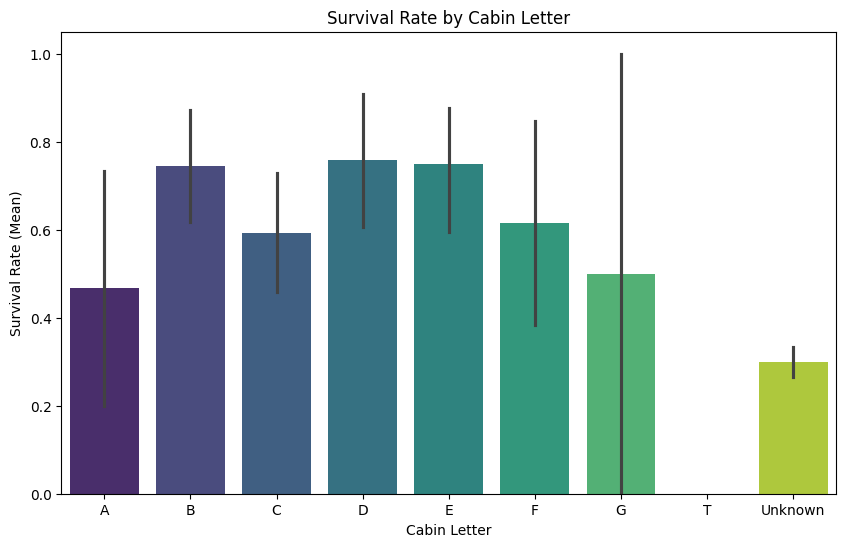

In [82]:
# Set the order so it's easy to read (A-G, then T and Unknown)
cabin_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'Unknown']

plt.figure(figsize=(10, 6))
sns.barplot(x='CabinLetter', y='Survived', data=train, order=cabin_order, palette='viridis')

plt.title('Survival Rate by Cabin Letter')
plt.ylabel('Survival Rate (Mean)')
plt.xlabel('Cabin Letter')
plt.show()

**Having cabin increases your survival rate.**
**However, Cabin T has zero survival rate**

In [83]:
# Count only the rows where CabinLetter is 'T'
t_count = (train['CabinLetter'] == 'T').sum()
print(f"Number of passengers in Cabin T: {t_count}")

Number of passengers in Cabin T: 1


**As there is only one passenger in Cabin T it can be a noise in the data** **Hence, I should either mix Cabin T to Unknown or drop it**

In [84]:
# Extract cabin letter from cabin
train['CabinLetter'] = train['Cabin'].str[0].fillna('Unknown')

# How many unique cabin letter
unique_cabin = train['CabinLetter'].unique()
print("Unique cabin letter:", unique_cabin)
print("Number of unique cabin letters:", len(unique_cabin))

#Mix Cabin T with Unknown
train['CabinLetter'] = train['CabinLetter'].replace('T', 'Unknown')

#Create new column for each letter
# One-hot encode CabinLetter directly as integers
cabin_dummies = pd.get_dummies(train['CabinLetter'], prefix='Cabin', dtype=int)
train = pd.concat([train, cabin_dummies], axis=1)

# Drop the redundant 'Cabin_Unknown' column
if 'Cabin_Unknown' in train.columns:
    train.drop('Cabin_Unknown', axis=1, inplace=True)

#Remove duplicate columns if they exist
train = train.loc[:, ~train.columns.duplicated()]

Unique cabin letter: ['Unknown' 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']
Number of unique cabin letters: 9


In [88]:
# Recheck: Count only the rows where CabinLetter is 'T'
t_count = (train['CabinLetter'] == 'T').sum()
print(f"Number of passengers in Cabin T: {t_count}")

Number of passengers in Cabin T: 0


/tmp/ipykernel_55/1428200693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CabinLetter', y='Survived', data=train, order=cabin_order, palette='viridis')


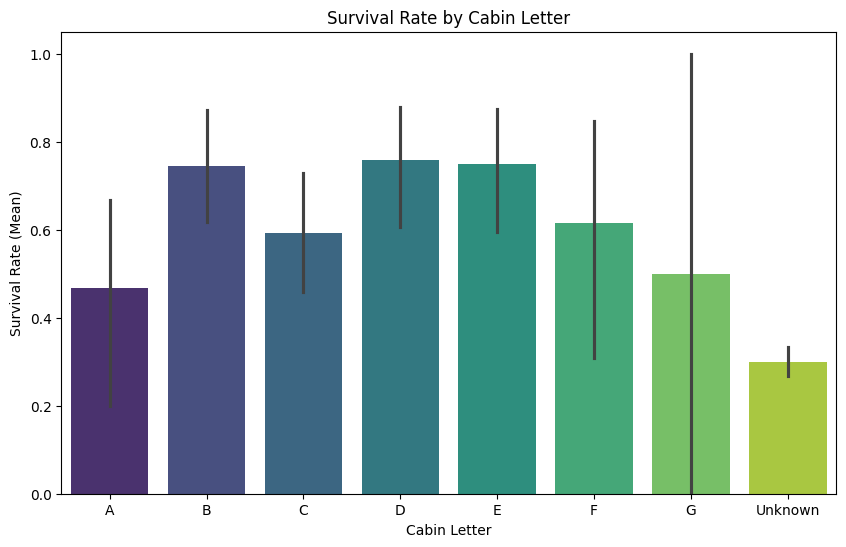

In [86]:
# Set the order so it's easy to read (A-G, then T and Unknown)
cabin_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']

plt.figure(figsize=(10, 6))
sns.barplot(x='CabinLetter', y='Survived', data=train, order=cabin_order, palette='viridis')

plt.title('Survival Rate by Cabin Letter')
plt.ylabel('Survival Rate (Mean)')
plt.xlabel('Cabin Letter')
plt.show()

# Utilise Ticket numbers

In [101]:
# Create a binary column: 1 if the ticket is digits only, 0 if it has letters
train['TicketNumeric'] = train['Ticket'].str.isdigit().astype(int)

# Let's see the survival difference between the two
analysis = train.groupby('TicketNumeric')['Survived'].mean()
print("Survival Rate (0 = Prefix, 1 = Only Numbers):")
print(analysis)

Survival Rate (0 = Prefix, 1 = Only Numbers):
TicketNumeric
0    0.382609
1    0.384266
Name: Survived, dtype: float64


**As having numeric or not does not show a clear difference in survival, I will drop the column**

In [102]:
#dropping the TicketNumeric column
train.drop('TicketNumeric', axis=1, inplace=True)

# Utilise Embarked info

/tmp/ipykernel_55/320463491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=train, palette='magma')


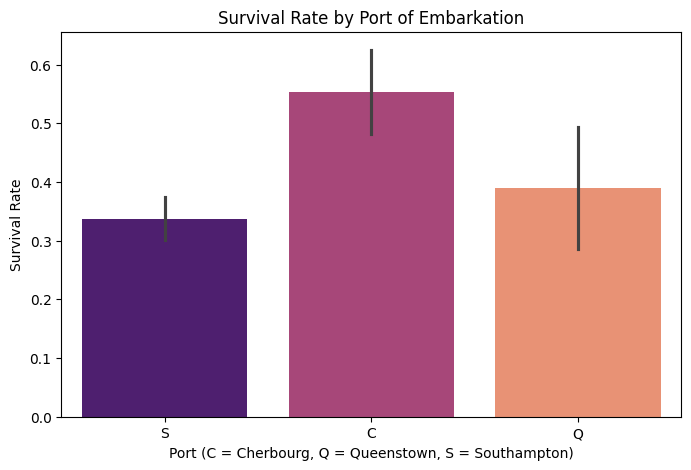

In [95]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Embarked', y='Survived', data=train, palette='magma')

plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.show()

**According to the bar graph, C has a higher Survival rate, it is worth including it**

In [105]:
# 1. Check if 'Embarked' still exists in the dataframe
if 'Embarked' in train.columns:
    # Fill missing values
    train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

    # 2. Create dummies (using drop_first=True to avoid the trap)
    embarked_dummies = pd.get_dummies(train['Embarked'], prefix='Embarked', drop_first=True, dtype=int)

    # 3. Join back
    train = pd.concat([train, embarked_dummies], axis=1)

    # 4. Drop the original text column so we don't try to use it again
    train.drop('Embarked', axis=1, inplace=True)
    print("Embarked column encoded successfully.")
else:
    print("Embarked column not found")

#train.head()

Embarked column not found


# Process 2: Time to usitilise these features in the models

In [109]:
train.columns
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Sex_num,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,False,False,False,False,False,False,False,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,False,True,False,False,False,False,False,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,False,False,False,False,False,False,False,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,False,True,False,False,False,False,False,1,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,False,False,False,False,False,False,False,0,0,1


**XGB (highest accuracy in the past 83.5)**

In [112]:
#Import
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBRegressor
from xgboost import XGBClassifier

#target (what to predict)
y = train['Survived']


#freatures 
features = [
    "Pclass", "Age" "SibSp", "Parch", "FarePerPerson", 
    "Sex_num", "HasCabin", "isChild", "isAdult", "isElderly", 
    'Cabin_A', 'Cabin_B', 'Cabin_C','Cabin_D', 'Cabin_E', 'Cabin_F','Cabin_G', 
    'Embarked_Q', 'Embarked_S'
]

X = train[features]

xgb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])
scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)


#print("MAE:", -scores.mean())
print("Accuracy:", scores.mean())

Accuracy: 0.8226602222082733
